In [1]:
#  import required libraries
import os as os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from pprint import pprint
from sklearn.model_selection import GridSearchCV

In [2]:
# Loading the data
os.chdir("D:\Intern\Edu-Versity\Project 4")
print(os.getcwd())
train = pd.read_csv("train_cab_fare.csv")
test = pd.read_csv("test_cab_fare.csv")

D:\Intern\Edu-Versity\Project 4


<>:2: SyntaxWarning: invalid escape sequence '\I'
<>:2: SyntaxWarning: invalid escape sequence '\I'
C:\Users\amogh\AppData\Local\Temp\ipykernel_6032\3547298548.py:2: SyntaxWarning: invalid escape sequence '\I'
  os.chdir("D:\Intern\Edu-Versity\Project 4")


In [3]:
print("DataTypes of Train set\n",train.dtypes,"\nDataTypes of Test set\n",test.dtypes)

DataTypes of Train set
 fare_amount           object
pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count      float64
dtype: object 
DataTypes of Test set
 pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object


In [4]:
print("\n",train.columns,"\n",test.columns)


 Index(['fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count'],
      dtype='object') 
 Index(['pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count'],
      dtype='object')


In [5]:
train.describe, test.describe

(<bound method NDFrame.describe of       fare_amount          pickup_datetime  pickup_longitude  pickup_latitude  \
 0             4.5  2009-06-15 17:26:21 UTC        -73.844311        40.721319   
 1            16.9  2010-01-05 16:52:16 UTC        -74.016048        40.711303   
 2             5.7  2011-08-18 00:35:00 UTC        -73.982738        40.761270   
 3             7.7  2012-04-21 04:30:42 UTC        -73.987130        40.733143   
 4             5.3  2010-03-09 07:51:00 UTC        -73.968095        40.768008   
 ...           ...                      ...               ...              ...   
 16062         6.5  2014-12-12 07:41:00 UTC        -74.008820        40.718757   
 16063        16.1  2009-07-13 07:58:00 UTC        -73.981310        40.781695   
 16064         8.5  2009-11-11 11:19:07 UTC        -73.972507        40.753417   
 16065         8.1  2010-05-11 23:53:00 UTC        -73.957027        40.765945   
 16066         8.5  2011-12-14 06:24:33 UTC        -74.002111   

In [6]:
train.describe(), test.describe()

(       pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
 count      16067.000000     16067.000000       16067.000000      16067.000000   
 mean         -72.462787        39.914725         -72.462328         39.897906   
 std           10.578384         6.826587          10.575062          6.187087   
 min          -74.438233       -74.006893         -74.429332        -74.006377   
 25%          -73.992156        40.734927         -73.991182         40.734651   
 50%          -73.981698        40.752603         -73.980172         40.753567   
 75%          -73.966838        40.767381         -73.963642         40.768014   
 max           40.766125       401.083332          40.802437         41.366138   
 
        passenger_count  
 count     16012.000000  
 mean          2.625070  
 std          60.844122  
 min           0.000000  
 25%           1.000000  
 50%           1.000000  
 75%           2.000000  
 max        5345.000000  ,
        pickup_longitude 

In [7]:
print("Train Dimension:",train.shape,"\nTest Dimension:",test.shape)

Train Dimension: (16067, 7) 
Test Dimension: (9914, 6)


In [8]:
#Converting the fare amount from oject to numneric
train["fare_amount"] = pd.to_numeric(train["fare_amount"],errors = "coerce")
#Droping NA values
train.dropna(subset = ["pickup_datetime"])

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1.0
1,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1.0
2,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2.0
3,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1.0
4,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1.0
...,...,...,...,...,...,...,...
16062,6.5,2014-12-12 07:41:00 UTC,-74.008820,40.718757,-73.998865,40.719987,1.0
16063,16.1,2009-07-13 07:58:00 UTC,-73.981310,40.781695,-74.014392,40.715527,2.0
16064,8.5,2009-11-11 11:19:07 UTC,-73.972507,40.753417,-73.979577,40.765495,1.0
16065,8.1,2010-05-11 23:53:00 UTC,-73.957027,40.765945,-73.981983,40.779560,1.0


In [9]:
# Converting pickup_datetime from object to datetime
train["pickup_datetime"] = pd.to_datetime(train["pickup_datetime"], format='%Y-%m-%d %H:%M:%S UTC', errors='coerce')

In [10]:
#  we will be seperating the pickup_datetime function into year, month, day etc
train['Year'] = train['pickup_datetime'].dt.year
train['Month'] = train['pickup_datetime'].dt.month
train['Date'] = train['pickup_datetime'].dt.day
train['Day'] = train['pickup_datetime'].dt.dayofweek
train['Hour'] = train['pickup_datetime'].dt.hour
train['Minute'] = train['pickup_datetime'].dt.minute

In [11]:
# Converting pickup_datetime from object to datetime
test["pickup_datetime"] = pd.to_datetime(test["pickup_datetime"], format='%Y-%m-%d %H:%M:%S UTC', errors='coerce')

In [12]:
#  we will be seperating the pickup_datetime function into year, month, day etc
test['Year'] = test['pickup_datetime'].dt.year
test['Month'] = test['pickup_datetime'].dt.month
test['Date'] = test['pickup_datetime'].dt.day
test['Day'] = test['pickup_datetime'].dt.dayofweek
test['Hour'] = test['pickup_datetime'].dt.hour
test['Minute'] = test['pickup_datetime'].dt.minute

In [27]:
train = train.drop(train[train['pickup_datetime'].isnull()].index, axis = 0)
print(train['pickup_datetime'].isnull().sum())

0


In [14]:
train['passenger_count'].describe()

count    16011.000000
mean         2.625171
std         60.846021
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max       5345.000000
Name: passenger_count, dtype: float64

In [16]:
train = train.drop(train[train['passenger_count'] > 6].index, axis = 0)

In [17]:
train['passenger_count'].describe()

count    15991.000000
mean         1.643701
std          1.267504
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          6.000000
Name: passenger_count, dtype: float64

In [18]:
train = train.drop(train[train['passenger_count'] == 0].index, axis = 0)

In [19]:
train['passenger_count'].describe()

count    15934.000000
mean         1.649581
std          1.265943
min          0.120000
25%          1.000000
50%          1.000000
75%          2.000000
max          6.000000
Name: passenger_count, dtype: float64

In [20]:
train["passenger_count"].sort_values(ascending = True)

8862     0.12
0        1.00
9790     1.00
9791     1.00
9792     1.00
         ... 
8076      NaN
8139      NaN
8259      NaN
8306      NaN
16066     NaN
Name: passenger_count, Length: 15989, dtype: float64

In [28]:
#  removing passenger_count missing values rows
train = train.drop(train[train['passenger_count'].isnull()].index, axis = 0)
print(train['passenger_count'].isnull().sum())

0


In [23]:
train = train.drop(train[train['passenger_count'] == 0.12].index, axis = 0)

In [26]:
train['fare_amount'].sort_values(ascending = False)

1015    54343.0
1072     4343.0
607       453.0
980       434.0
1335      180.0
         ...   
1712        NaN
2412        NaN
2458        NaN
8178        NaN
8226        NaN
Name: fare_amount, Length: 15933, dtype: float64

In [33]:
# count the number of rows where fare amount is less than 0
Counter(train['fare_amount'] < 0)

Counter({False: 15926})

In [34]:
# remove the negative values in the fare_amount column
train = train.drop(train[train['fare_amount'] < 0].index, axis = 0)
train['fare_amount'].min()

1.14

In [35]:
# removing all the value of tyhe fare_amount closer to 0
train = train.drop(train[train['fare_amount'] < 1].index, axis = 0)
# removing the outliers in the fare_amount especially the top 3 values which have a huge difference
train = train.drop(train[train['fare_amount'] > 454].index, axis = 0)
train.shape

(15926, 13)

In [36]:
# removing the missing values rows in the fare_amount 
train = train.drop(train[train['fare_amount'].isnull()].index, axis = 0)
print(train.shape)
print(train['fare_amount'].isnull().sum())

(15902, 13)
0


In [37]:
train['fare_amount'].sort_values(ascending = False)

607      453.00
980      434.00
1335     180.00
1483     165.00
6630     128.83
          ...  
8596       2.50
7918       2.50
8603       2.50
15490      2.50
1427       1.14
Name: fare_amount, Length: 15902, dtype: float64

In [38]:
train['fare_amount'].describe()

count    15902.000000
mean        11.376356
std         10.814908
min          1.140000
25%          6.000000
50%          8.500000
75%         12.500000
max        453.000000
Name: fare_amount, dtype: float64

In [39]:
# removing the outliers who are not in range
train = train.drop(train[train['pickup_latitude'] < -90 ].index, axis = 0)
train = train.drop(train[train['pickup_latitude'] > 90 ].index, axis = 0)
print(train.shape)

(15901, 13)


In [40]:
train.isnull().sum()

fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
Year                 0
Month                0
Date                 0
Day                  0
Hour                 0
Minute               0
dtype: int64

In [41]:
from math import radians, cos, sin, asin, sqrt
def haversine(a):
    lon1 = a[0]
    lat1 = a[1]
    lon2 = a[2]
    lat2 = a[3]

    #Calculating the great circle between two points on the earth(specified in decimal degrees)
    # convert decimal degrees into adians
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    # radius of the eartyh in km is 6371
    km = 6371 * c
    return km

In [44]:
train["distance"] = train[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']].apply(haversine, axis = 1)
test["distance"] = test[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']].apply(haversine, axis = 1)

C:\Users\amogh\AppData\Local\Temp\ipykernel_6032\2927099950.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lon1 = a[0]
C:\Users\amogh\AppData\Local\Temp\ipykernel_6032\2927099950.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lat1 = a[1]
C:\Users\amogh\AppData\Local\Temp\ipykernel_6032\2927099950.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lon2 = a[2]
C:\Users\amogh\AppData\Local\Temp\ipykernel_6032\2927099950.py:6

In [48]:
train.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Date,Day,Hour,Minute,distance
0,4.5,2009-06-15 17:26:21,-73.844311,40.721319,-73.841610,40.712278,1.0,2009.0,6.0,15.0,0.0,17.0,26.0,1.030764
1,16.9,2010-01-05 16:52:16,-74.016048,40.711303,-73.979268,40.782004,1.0,2010.0,1.0,5.0,1.0,16.0,52.0,8.450134
2,5.7,2011-08-18 00:35:00,-73.982738,40.761270,-73.991242,40.750562,2.0,2011.0,8.0,18.0,3.0,0.0,35.0,1.389525
3,7.7,2012-04-21 04:30:42,-73.987130,40.733143,-73.991567,40.758092,1.0,2012.0,4.0,21.0,5.0,4.0,30.0,2.799270
4,5.3,2010-03-09 07:51:00,-73.968095,40.768008,-73.956655,40.783762,1.0,2010.0,3.0,9.0,1.0,7.0,51.0,1.999157


In [49]:
test.head()

,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Date,Day,Hour,Minute,distance
0,2015-01-27 13:08:24,-73.973320,40.763805,-73.981430,40.743835,1,2015,1,27,1,13,8,2.323259
1,2015-01-27 13:08:24,-73.986862,40.719383,-73.998886,40.739201,1,2015,1,27,1,13,8,2.425353
2,2011-10-08 11:53:44,-73.982524,40.751260,-73.979654,40.746139,1,2011,10,8,5,11,53,0.618628
3,2012-12-01 21:12:12,-73.981160,40.767807,-73.990448,40.751635,1,2012,12,1,5,21,12,1.961033
4,2012-12-01 21:12:12,-73.966046,40.789775,-73.988565,40.744427,1,2012,12,1,5,21,12,5.387301


In [50]:
train.nunique()

fare_amount            449
pickup_datetime      15380
pickup_longitude     13533
pickup_latitude      13969
dropoff_longitude    13626
dropoff_latitude     13995
passenger_count          7
Year                     7
Month                   12
Date                    31
Day                      7
Hour                    24
Minute                  60
distance             15424
dtype: int64

In [51]:
test.nunique()

pickup_datetime      1751
pickup_longitude     9051
pickup_latitude      9175
dropoff_longitude    9070
dropoff_latitude     9290
passenger_count         6
Year                    7
Month                  12
Date                   31
Day                     7
Hour                   24
Minute                 60
distance             9829
dtype: int64

In [52]:
#  checking the outliers in the distance column
train['distance'].sort_values(ascending = False)

10710    129.950482
14536    129.560455
11619    127.509261
12228    123.561157
5663     101.094619
            ...    
13488      0.000344
510        0.000279
15366      0.000238
13582      0.000202
15490      0.000111
Name: distance, Length: 15424, dtype: float64

In [63]:
#  we will remove the rows whose distancee value is very high which is more than 129km
train = train.drop(train[train['distance'] > 130 ].index, axis = 0)
Counter(train['distance'] == 0)
Counter(test['distance'] == 0)

Counter({False: 9829})

In [64]:
# we need to drop all the distance values which are equal to 0
train = train.drop(train[train['distance'] == 0 ].index, axis = 0)
test = test.drop(test[test['distance'] == 0 ].index, axis = 0)

In [65]:
train.head()

,fare_amount,passenger_count,Year,Month,Date,Day,Hour,distance
0,4.5,1.0,2009.0,6.0,15.0,0.0,17.0,1.030764
1,16.9,1.0,2010.0,1.0,5.0,1.0,16.0,8.450134
2,5.7,2.0,2011.0,8.0,18.0,3.0,0.0,1.389525
3,7.7,1.0,2012.0,4.0,21.0,5.0,4.0,2.799270
4,5.3,1.0,2010.0,3.0,9.0,1.0,7.0,1.999157


In [61]:
drop_columns = ['pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'Minute']
test = test.drop(drop_columns, axis = 1)
test.head()

,passenger_count,Year,Month,Date,Day,Hour,distance
0,1,2015,1,27,1,13,2.323259
1,1,2015,1,27,1,13,2.425353
2,1,2011,10,8,5,11,0.618628
3,1,2012,12,1,5,21,1.961033
4,1,2012,12,1,5,21,5.387301


In [68]:
# converting variables of float datatype to int datatype
train["passenger_count"] = train["passenger_count"].astype('int64')
train["Year"] = train["Year"].astype('int64')
train["Month"] = train["Month"].astype('int64')
train["Date"] = train["Date"].astype('int64')
train["Day"] = train["Day"].astype('int64')
train["Hour"] = train["Hour"].astype('int64')

In [69]:
train.dtypes

fare_amount        float64
passenger_count      int64
Year                 int64
Month                int64
Date                 int64
Day                  int64
Hour                 int64
distance           float64
dtype: object

<Axes: xlabel='passenger_count', ylabel='count'>

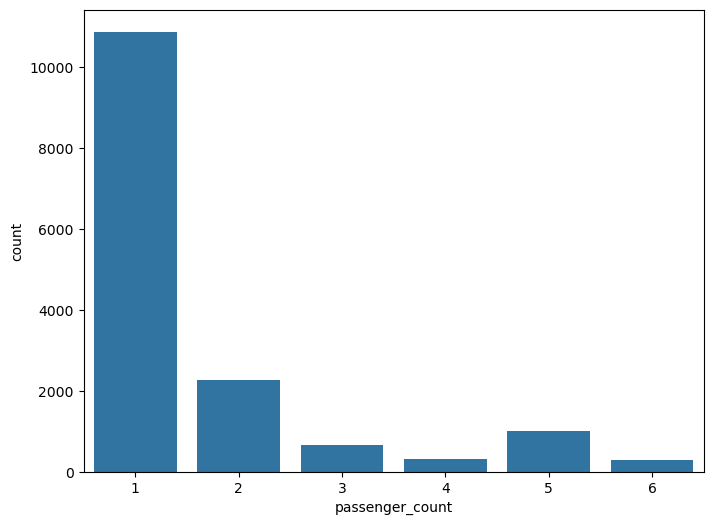

In [72]:
# Data Visualization
# counting the number of passenger vs number of rides
plt.figure(figsize = (8,6))
sns.countplot(x = 'passenger_count', data = train)

In [ ]:
# Single and double travelling passengers are the most frequent rides taken

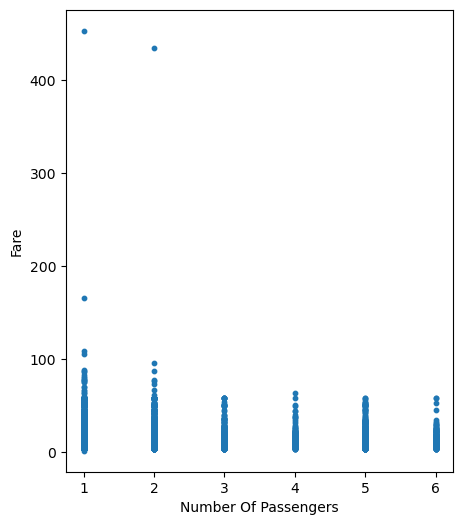

In [73]:
# relationship between number of passenger and fare
plt.figure(figsize = (5,6))
plt.scatter(x = train['passenger_count'], y = train['fare_amount'], s =10)
plt.xlabel('Number Of Passengers')
plt.ylabel('Fare')
plt.show()

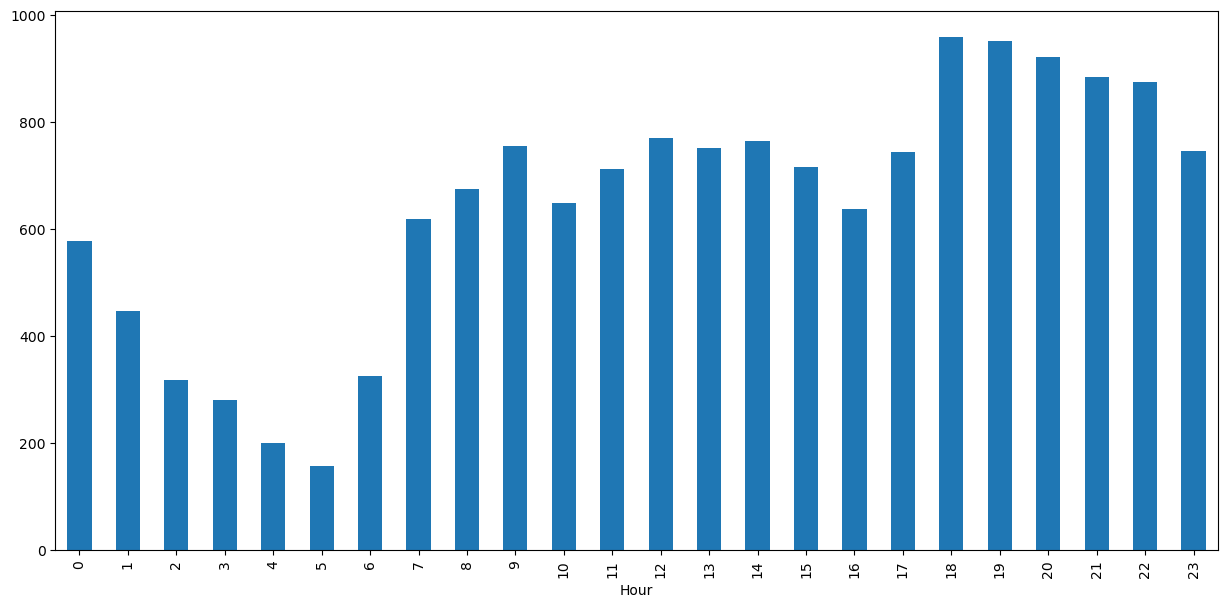

In [74]:
# relationship between hour and fare
plt.figure(figsize = (15,7))
train.groupby(train['Hour'])['Hour'].count().plot(kind = "bar")
plt.show()

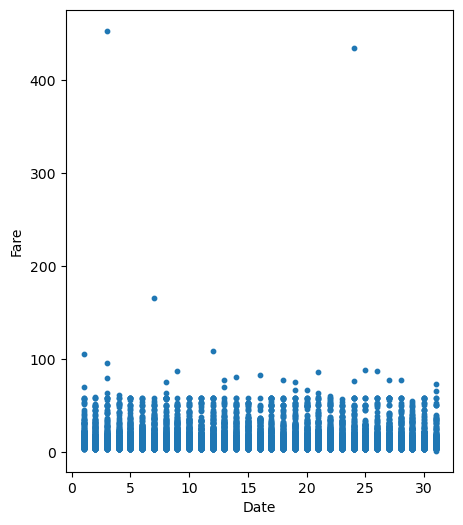

In [75]:
# relationship between date and fare
plt.figure(figsize = (5,6))
plt.scatter(x = train['Date'], y = train['fare_amount'], s =10)
plt.xlabel('Date')
plt.ylabel('Fare')
plt.show()

In [ ]:
# lowest number of cabs at around 5am and highest number of cabs between 6pm to 7pm 

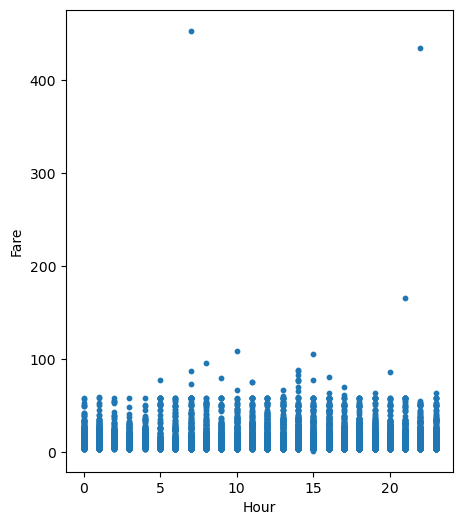

In [76]:
# relationship between time of the day and fare
plt.figure(figsize = (5,6))
plt.scatter(x = train['Hour'], y = train['fare_amount'], s =10)
plt.xlabel('Hour')
plt.ylabel('Fare')
plt.show()

<Axes: xlabel='Day', ylabel='count'>

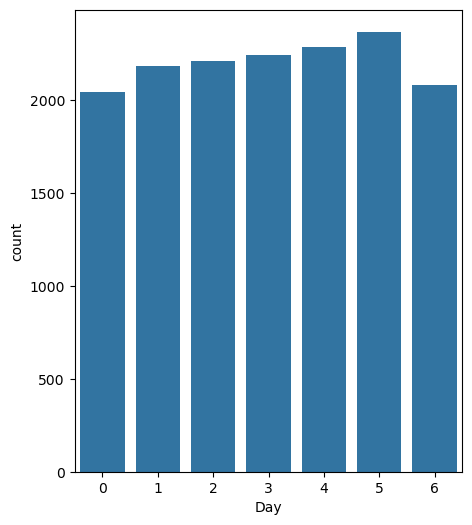

In [77]:
# impact of the day on the cab rides
plt.figure(figsize = (5,6))
sns.countplot(x = 'Day', data = train)

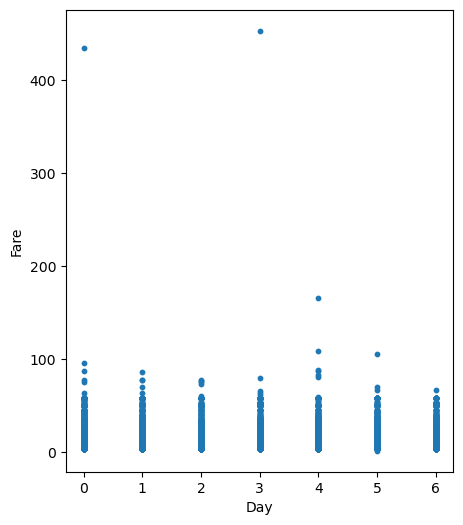

In [79]:
# relatuionship between the day of the week ansd fare
plt.figure(figsize = (5,6))
plt.scatter(x = train['Day'], y = train['fare_amount'], s =10)
plt.xlabel('Day')
plt.ylabel('Fare')
plt.show()

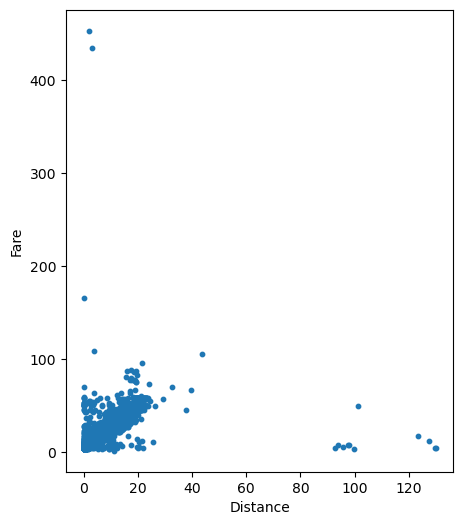

In [80]:
# relationship between distance and fare
plt.figure(figsize = (5,6))
plt.scatter(x = train['distance'], y = train['fare_amount'], s =10)
plt.xlabel('Distance')
plt.ylabel('Fare')
plt.show()

fare_amount


C:\Users\amogh\AppData\Local\Temp\ipykernel_6032\4012568922.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train[i], bins = 'auto', color = 'green')


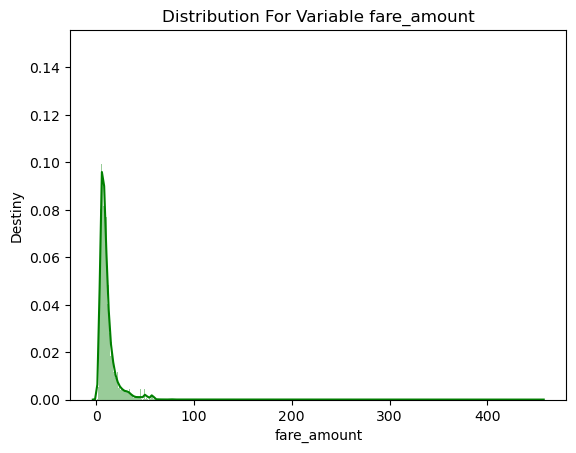

distance


C:\Users\amogh\AppData\Local\Temp\ipykernel_6032\4012568922.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train[i], bins = 'auto', color = 'green')


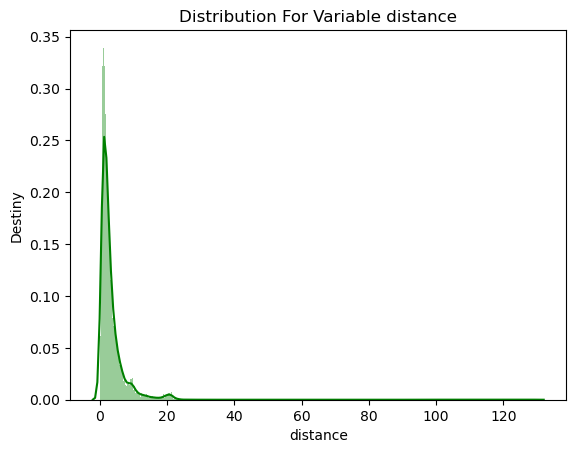

In [81]:
for i in ['fare_amount', 'distance']:
    print(i)
    sns.distplot(train[i], bins = 'auto', color = 'green')
    plt.title("Distribution For Variable " +i)
    plt.ylabel("Destiny")
    plt.show()

In [82]:
# since the fare amount is highly skewed applying log transformation to reduce the skewness
train['fare_amount'] = np.log1p(train['fare_amount'])
# since the distance is highly skewed applying log transformation to reduce the skewness
train['distance'] = np.log1p(train['distance'])

fare_amount


C:\Users\amogh\AppData\Local\Temp\ipykernel_6032\3113262706.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train[i], bins = 'auto', color = 'green')


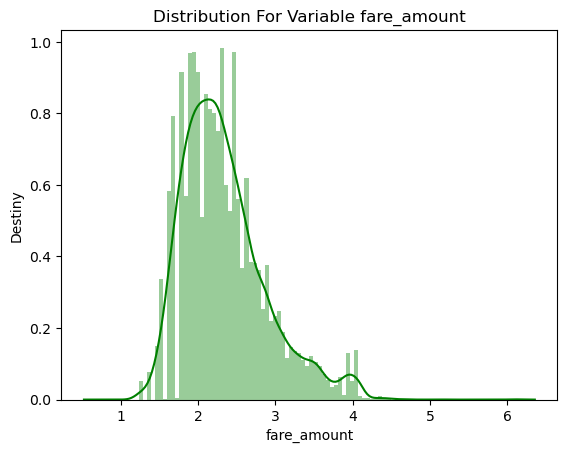

distance


C:\Users\amogh\AppData\Local\Temp\ipykernel_6032\3113262706.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train[i], bins = 'auto', color = 'green')


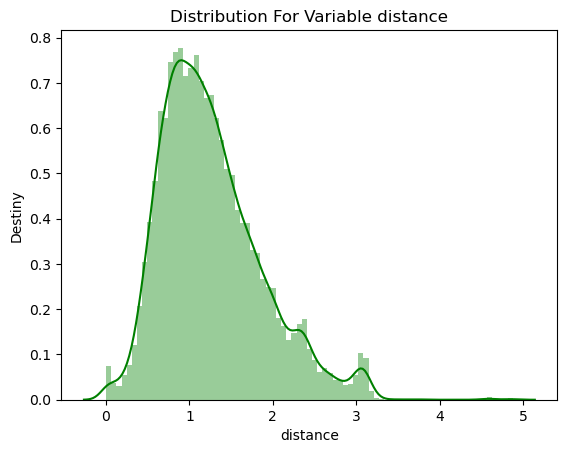

In [83]:
# normality re-check  the data is uniformly distributed or not after log transformation
for i in ['fare_amount', 'distance']:
    print(i)
    sns.distplot(train[i], bins = 'auto', color = 'green')
    plt.title("Distribution For Variable " +i)
    plt.ylabel("Destiny")
    plt.show()

distance


C:\Users\DELL\AppData\Local\Temp\ipykernel_5672\2140233688.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(test[i], bins = 'auto', color = 'green')


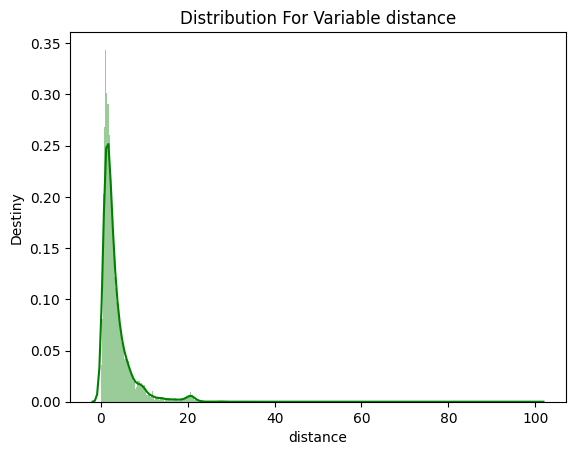

In [192]:
# normality check for the test data for the cab fare and distance

for i in ['distance']:
    print(i)
    sns.distplot(test[i], bins = 'auto', color = 'green')
    plt.title("Distribution For Variable " +i)
    plt.ylabel("Destiny")
    plt.show()

distance


C:\Users\amogh\AppData\Local\Temp\ipykernel_6032\1650477331.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(test[i], bins = 'auto', color = 'green')


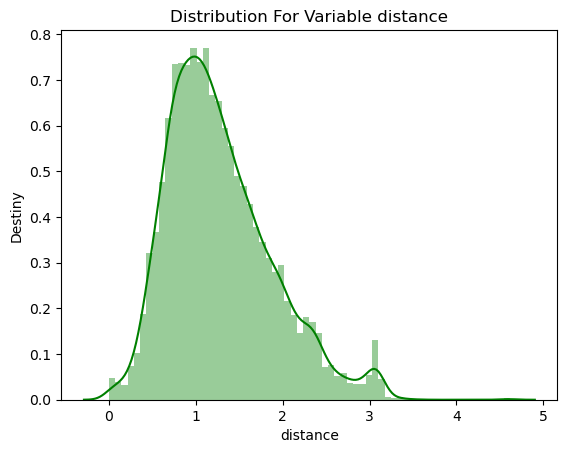

In [84]:
# normality re-check  the data is uniformly distributed or not after log transformation
# since the distance is highly skewed applying log transformation to reduce the skewness
test['distance'] = np.log1p(test['distance'])

for i in ['distance']:
    print(i)
    sns.distplot(test[i], bins = 'auto', color = 'green')
    plt.title("Distribution For Variable " +i)
    plt.ylabel("Destiny")
    plt.show()

In [86]:
# applying train test split on the dataset
x_train, x_test, y_train, y_test =  train_test_split(train.iloc[:,train.columns != 'fare_amount'], train.iloc[:, 0], test_size = 0.2, random_state = 1)

In [87]:
x_train, x_test, y_train, y_test

(       passenger_count  Year  Month  Date  Day  Hour  distance
 7690                 2  2012      5    16    2     6  1.691253
 13018                1  2014      7    11    4    10  0.828231
 12950                3  2009      6    27    5    17  0.980620
 14009                1  2009      6    12    4    15  0.534072
 2816                 5  2013      5    18    5    20  1.141300
 ...                ...   ...    ...   ...  ...   ...       ...
 994                  1  2009      3    24    1    11  1.465260
 5454                 1  2014      1    11    5    18  0.666875
 12682                6  2014      1     7    1     9  1.437090
 259                  1  2013      5     2    3     3  0.803939
 13919                1  2012      3    20    1    16  2.365173
 
 [12339 rows x 7 columns],
        passenger_count  Year  Month  Date  Day  Hour  distance
 1950                 1  2011      6    17    4     9  0.875383
 11386                1  2014     10    10    4    23  1.886420
 9920      

In [201]:
print(x_train.shape)
print(x_test.shape)

(12339, 7)
(3085, 7)


In [202]:
print(y_train.shape)
print(y_test.shape)

(12339,)
(3085,)


In [ ]:
# Linear Regression

In [88]:
# Building model on the top of the training dataset
LR = LinearRegression().fit(x_train, y_train)
trainLR =LR.predict(x_train)
testLR =LR.predict(x_test)

In [89]:
# calculating RMSE for the test data
RMSEtestLR = np.sqrt(mean_squared_error(y_test, testLR))

# calculating RMSE for the train data
RMSEtrainLR = np.sqrt(mean_squared_error(y_train, trainLR))

In [90]:
print("ROOT MEAN SQUARE ERROR FOR THE TRAINING DATA = " + str(RMSEtrainLR))
print("ROOT MEAN SQUARE ERROR FOR THE TEST DATA = " + str(RMSEtestLR))

ROOT MEAN SQUARE ERROR FOR THE TRAINING DATA = 0.2753110017967311
ROOT MEAN SQUARE ERROR FOR THE TEST DATA = 0.24540661786977663


In [97]:
# Calculate R^2 for the train data
from sklearn.metrics import r2_score
print(r2_score(y_train, trainLR)*100)
print(r2_score(y_test,testLR)*100)

74.9550265188041
78.27019104296612


In [ ]:
# Decsion Tree Model

In [98]:
fit_DT = DecisionTreeRegressor(max_depth = 2).fit(x_train, y_train)
pred_test_DT = fit_DT.predict(x_test)
pred_train_DT = fit_DT.predict(x_train)

In [100]:
# calculating RMSE for the train data
RMSE_train_DT = np.sqrt(mean_squared_error(y_train, pred_train_DT))
# calculating RMSE for the test data
RMSE_test_DT = np.sqrt(mean_squared_error(y_test, pred_test_DT))

In [102]:
print("ROOT MEAN SQUARE ERROR FOR THE TRAINING DATA = " + str(RMSE_train_DT))
print("ROOT MEAN SQUARE ERROR FOR THE TEST DATA = " + str(RMSE_test_DT))

ROOT MEAN SQUARE ERROR FOR THE TRAINING DATA = 0.2996210902077019
ROOT MEAN SQUARE ERROR FOR THE TEST DATA = 0.2867460617158616


In [108]:
# Calculate R^2 for the train data
from sklearn.metrics import r2_score
r2_score(y_train, pred_train_DT)*100

70.33678616157003

In [107]:
r2_score(y_test, testLR)*100

78.27019104296612

In [111]:
# Random Forest Model
fit_RF = RandomForestRegressor(n_estimators = 200).fit(x_train, y_train)
pred_train_RF = fit_DT.predict(x_train)
pred_test_RF = fit_RF.predict(x_test)

In [112]:
# calculating RMSE for the test data
RMSE_test_RF = np.sqrt(mean_squared_error(y_test, pred_test_RF))
# calculating RMSE for the train data
RMSE_train_RF = np.sqrt(mean_squared_error(y_train, pred_train_RF))

In [113]:
print("ROOT MEAN SQUARE ERROR FOR THE TRAINING DATA = " + str(RMSE_train_RF))
print("ROOT MEAN SQUARE ERROR FOR THE TEST DATA = " + str(RMSE_test_RF))

ROOT MEAN SQUARE ERROR FOR THE TRAINING DATA = 0.2996210902077019
ROOT MEAN SQUARE ERROR FOR THE TEST DATA = 0.23518616700085831


In [114]:
# Calculate R^2 for the train data
from sklearn.metrics import r2_score
print(r2_score(y_train, pred_train_RF)*100)
print(r2_score(y_test, pred_test_RF)*100)

70.33678616157003
80.04246423865105


In [115]:
# Gradient Boosting
fit_GB = GradientBoostingRegressor().fit(x_train, y_train)
pred_train_GB = fit_GB.predict(x_train)
pred_test_GB = fit_GB.predict(x_test)

In [116]:
# calculating RMSE for the test data
RMSE_test_GB = np.sqrt(mean_squared_error(y_test, pred_test_GB))
# calculating RMSE for the train data
RMSE_train_GB = np.sqrt(mean_squared_error(y_train, pred_train_GB))

In [117]:
print("ROOT MEAN SQUARE ERROR FOR THE TRAINING DATA = " + str(RMSE_train_GB))
print("ROOT MEAN SQUARE ERROR FOR THE TEST DATA = " + str(RMSE_test_GB))

ROOT MEAN SQUARE ERROR FOR THE TRAINING DATA = 0.22754316149645537
ROOT MEAN SQUARE ERROR FOR THE TEST DATA = 0.22730129365106488


In [119]:
# Calculate R^2 for the train data
from sklearn.metrics import r2_score
print(r2_score(y_train, pred_train_GB)*100)
print(r2_score(y_test, pred_test_GB)*100)

82.89193000175024
81.35822839713286


In [122]:
#Parameter Tuning
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state = 42)
from pprint import pprint
# look at parameter used by our current post
print("PARAMETER CURRENTLY IN USE :\n")
pprint(rf.get_params())

PARAMETER CURRENTLY IN USE :

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}


In [123]:
#Random Hyperparameter Grid
from sklearn.model_selection import train_test_split, RandomizedSearchCV

In [132]:
#  random search cv on random forest model
RRF = RandomForestRegressor(random_state = 42)
n_estimator = list(range(1,20,2))
depth = list(range(1,100,2))
# create a random grid
rand_grid = {'n_estimators' : n_estimator, 'max_depth' : depth}

randomcv_rf = RandomizedSearchCV(RRF, param_distributions = rand_grid, n_iter = 5, cv = 5, random_state = 0)
random_rf = randomcv_rf.fit(x_train, y_train)
predictions_RRF = randomcv_rf.predict(x_test)

view_best_params_RRF = randomcv_rf.best_params_
best_model = randomcv_rf.best_estimator_
predictions_RRF = best_model.predict(x_test)

# r^2
RRF_r2 = r2_score(y_test, predictions_RRF)
# calculating RMSE
RRF_rmse = np.sqrt(mean_squared_error(y_test, predictions_RRF))
print("RANDOM SEARCH CV RANDOM FOREST REGRESSOR MODEL PERFORMANCE : ")
print("BEST PARAMETERS = ",view_best_params_RRF)
print("R-SQUARED = {:0.2}", format(RRF_r2))
print("RMSE = ", RRF_rmse)

RANDOM SEARCH CV RANDOM FOREST REGRESSOR MODEL PERFORMANCE : 
BEST PARAMETERS =  {'n_estimators': 15, 'max_depth': 9}
R-SQUARED = {:0.2} 0.7999644096921891
RMSE =  0.23545718751727365


In [125]:
gb = GradientBoostingRegressor(random_state = 42)
from pprint import pprint
# look at parameter used by our current post
print("PARAMETER CURRENTLY IN USE :\n")
pprint(rf.get_params())

PARAMETER CURRENTLY IN USE :

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}


In [133]:
#  random search cv on random forest model
gb = GradientBoostingRegressor(random_state = 42)
n_estimator = list(range(1,20,2))
depth = list(range(1,100,2))
# create a random grid
rand_grid = {'n_estimators' : n_estimator, 'max_depth' : depth}

randomcv_gb = RandomizedSearchCV(RRF, param_distributions = rand_grid, n_iter = 5, cv = 5, random_state = 0)
random_gb = randomcv_gb.fit(x_train, y_train)
predictions_gb = randomcv_gb.predict(x_test)

view_best_params_gb = randomcv_gb.best_params_
best_model = randomcv_rf.best_estimator_
predictions_gb = best_model.predict(x_test)

# r^2
gb_r2 = r2_score(y_test, predictions_gb)
# calculating RMSE
gb_rmse = np.sqrt(mean_squared_error(y_test, predictions_gb))
print("RANDOM SEARCH CV RANDOM FOREST REGRESSOR MODEL PERFORMANCE : ")
print("BEST PARAMETERS = ",view_best_params_gb)
print("R-SQUARED = {:0.2}", format(gb_r2))
print("RMSE = ", gb_rmse)

RANDOM SEARCH CV RANDOM FOREST REGRESSOR MODEL PERFORMANCE : 
BEST PARAMETERS =  {'n_estimators': 15, 'max_depth': 9}
R-SQUARED = {:0.2} 0.7999644096921891
RMSE =  0.23545718751727365


In [134]:
# Grid Search CV on random forest

GRF = RandomForestRegressor(random_state = 42)
n_estimator = list(range(11,20,1))
depth = list(range(5,15,2))
# create a grid search
grid_search = {'n_estimators' : n_estimator, 'max_depth' : depth}

gridcv_rf = GridSearchCV(GRF, param_grid = grid_search, cv = 5)
gridcv_RF = gridcv_rf.fit(x_train, y_train)
predictions_GRF = gridcv_rf.predict(x_test)

view_best_params_GRF = gridcv_RF.best_params_
best_model = gridcv_RF.best_estimator_
predictions_GRF = best_model.predict(x_test)

# r^2
GRF_r2 = r2_score(y_test, predictions_GRF)
# calculating RMSE
GRF_rmse = np.sqrt(mean_squared_error(y_test, predictions_GRF))
print("GRID SEARCH CV RANDOM FOREST REGRESSOR MODEL PERFORMANCE : ")
print("BEST PARAMETERS = ",view_best_params_GRF)
print("R-SQUARED = {:0.2}", format(GRF_r2))
print("RMSE = ", GRF_rmse)

GRID SEARCH CV RANDOM FOREST REGRESSOR MODEL PERFORMANCE : 
BEST PARAMETERS =  {'max_depth': 7, 'n_estimators': 19}
R-SQUARED = {:0.2} 0.8008121344738158
RMSE =  0.23495773935753111


In [135]:
# Grid Search CV on Gardient Boosting

GGB = GradientBoostingRegressor(random_state = 42)
n_estimator = list(range(11,20,1))
depth = list(range(5,15,2))
# create a grid search
grid_search = {'n_estimators' : n_estimator, 'max_depth' : depth}

gridcv_gb = GridSearchCV(GGB, param_grid = grid_search, cv = 5)
gridcv_GB = gridcv_gb.fit(x_train, y_train)
predictions_GRF = gridcv_GB.predict(x_test)

view_best_params_GGB = gridcv_GB.best_params_
best_model = gridcv_GB.best_estimator_
predictions_GGB = best_model.predict(x_test)

# r^2
GGB_r2 = r2_score(y_test, predictions_GGB)
# calculating RMSE
GGB_rmse = np.sqrt(mean_squared_error(y_test, predictions_GGB))
print("GRID SEARCH CV GRADIENT BOOSTING REGRESSOR MODEL PERFORMANCE : ")
print("BEST PARAMETERS = ",view_best_params_GGB)
print("R-SQUARED = {:0.2}", format(GGB_r2))
print("RMSE = ", GGB_rmse)


GRID SEARCH CV GRADIENT BOOSTING REGRESSOR MODEL PERFORMANCE : 
BEST PARAMETERS =  {'max_depth': 5, 'n_estimators': 19}
R-SQUARED = {:0.2} 0.7970819860937647
RMSE =  0.23714753650733425


In [137]:
test['Predicted_Fare'] = predictions_GRF_test
test.head()

,passenger_count,Year,Month,Date,Day,Hour,distance,Predicted_Fare
0,1,2015,1,27,1,13,1.200946,2.375434
1,1,2015,1,27,1,13,1.231205,2.394135
2,1,2011,10,8,5,11,0.481579,1.680705
3,1,2012,12,1,5,21,1.085538,2.218272
4,1,2012,12,1,5,21,1.854312,2.786595


In [140]:
test.to_csv('Finaldataset.csv')